In [81]:
import NpAutograd as npa
import numpy as np
from TrainHelpers import *
import VecOptim as vopt
from Autoencoder import Autoencoder
from NeuralNetwork import NeuralNetwork
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
train_data, train_labels, test_data, test_labels = get_mnist()

In [84]:
activation_function = lambda x: npa.leaky_relu(x, negative_slope=0.2)
encoder = Autoencoder(input_size=784, bottleneck_size=64, encoder_sizes = [256, 128], decoder_sizes = [128, 256], activation_function=npa.sigmoid, var=0.01)

In [99]:
probe = NeuralNetwork(input_size=784, output_size=10, activation=npa.relu, var=0.01)

0.09110920190260136
-0.015625000963888747
-0.007019227246435961
-0.12499999570672535
-0.050321651119710736
-0.031248007251451687
-0.11709823930838467
-0.04688141164913662
45.866825756633894


(array([ 19.,  61.,  83., 111., 104., 145., 110.,  79.,  51.,  21.]),
 array([0.01818026, 0.11279504, 0.20740981, 0.30202458, 0.39663935,
        0.49125412, 0.58586889, 0.68048366, 0.77509844, 0.86971321,
        0.96432798]),
 <BarContainer object of 10 artists>)

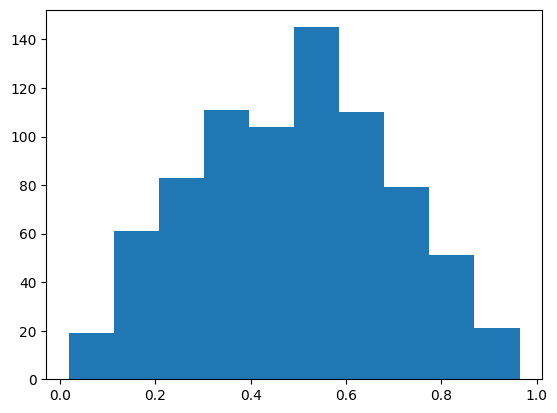

In [57]:
raw = train_data[0:1]
logits = encoder(raw)
probs = npa.sigmoid(logits)
loss = npa.BCELoss(probs, raw)
loss.backward()
for p in encoder.params:
    print(np.mean(p.v/(np.abs(p.v) + np.abs(p.grad))))
    p.zero_grad()
print(np.linalg.norm(encoder.params[0].v))
plt.hist(probs.v[0])

In [100]:
num_epochs = 50
batch_size = 256
schedule = cosine_annealing_schedule(num_epochs, batch_size, len(train_data), warmup_steps=0.1)
optim = vopt.Adam(encoder.get_params(), lr=1e-3, momentum=0.9, beta2=0.99, lr_func=schedule, reg_type="L2", reg_param=1e-6,)#beta2=0.9

In [101]:
losses = []
mags = []
for epoch in range(num_epochs):
    for b_x, b_y in batcher(train_data, train_labels, batch_size):
        #logits = encoder(b_x)
        #normalized = npa.sigmoid(logits)
        #loss = npa.BCELoss(normalized, b_x, reduction="mean") #b_x is treated as target since all inputs are normalized in [0,1]r
        logits = probe(b_x)
        probs = npa.softmax(logits)
        loss = npa.logloss(probs, b_y)
        loss.backward()
        cur_mags = [np.max(p.grad) for p in probe.get_params()]
        mags.append(cur_mags)
        # print([np.linalg.norm(p.grad) for p in encoder.get_params()])
        # raise ValueError
        optim.step()
        losses.append(loss.v)
        #print(cur_mags)
    print(f"epoch {epoch}, mean loss over last 10 updates: {np.mean(losses[-10:])}")
smoothed_losses = sma(np.array(losses))
plt.plot(smoothed_losses)
plt.plot(losses)
plt.show()
plt.plot(np.array(mags))

epoch 0, mean loss over last 10 updates: 3.2520811673400845
epoch 1, mean loss over last 10 updates: 3.255450583137145
epoch 2, mean loss over last 10 updates: 3.2562240472588355
epoch 3, mean loss over last 10 updates: 3.2517896972640985
epoch 4, mean loss over last 10 updates: 3.252294366418661
epoch 5, mean loss over last 10 updates: 3.253774714446787
epoch 6, mean loss over last 10 updates: 3.2561878560112447
epoch 7, mean loss over last 10 updates: 3.2540141702791416
epoch 8, mean loss over last 10 updates: 3.2533671536402045
epoch 9, mean loss over last 10 updates: 3.253253720719937
epoch 10, mean loss over last 10 updates: 3.252839600951743
epoch 11, mean loss over last 10 updates: 3.2502771470201837
epoch 12, mean loss over last 10 updates: 3.2539935129741324
epoch 13, mean loss over last 10 updates: 3.2570354611251653
epoch 14, mean loss over last 10 updates: 3.251754994659687
epoch 15, mean loss over last 10 updates: 3.2569262422795036
epoch 16, mean loss over last 10 updates

KeyboardInterrupt: 

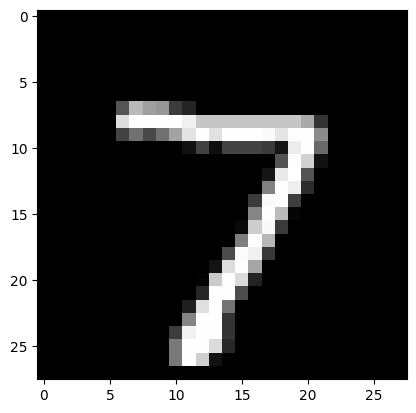

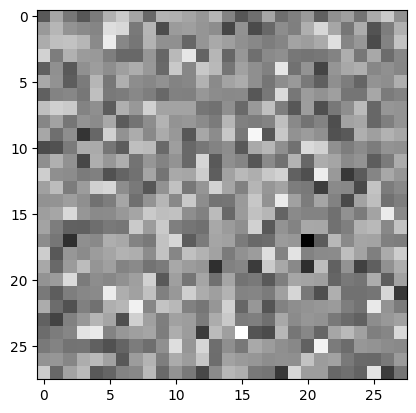

(10000, 784)


In [45]:
true_im = test_data[0]
pred_im = encoder(true_im).v
for im in [true_im, pred_im]:
    plt.imshow(im.reshape((28,28)), cmap="gray")
    plt.show()
print(test_data.shape)

In [46]:
for b_x, _ in batcher(test_data, test_labels, 1000):
    print(b_x.shape)

(1000, 784)
(1000, 784)
(1000, 784)
(1000, 784)
(1000, 784)
(1000, 784)
(1000, 784)
(1000, 784)
(1000, 784)
(1000, 784)
